==
Theme: Student Performance Analysis & Prediction
==

==
##
Task 1 — Data Exploration with Pandas
==

In [21]:
import pandas as pd

In [22]:
#Load the dataset: 

df = pd.read_csv("students.csv")

In [23]:
#Print the first 5 rows using .head()

print("First 5 rows:")
print(df.head())
print()

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  



In [24]:
# Shape and data types

print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)


Shape: (15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [25]:
# Summary statistics

print("Summary statistics:")
print(df.describe())
print()

Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

In [26]:
# Pass/Fail count

print("Pass/Fail count:")
print(df['passed'].value_counts())
print()

Pass/Fail count:
passed
1    9
0    6
Name: count, dtype: int64



In [27]:
# Average score per subject for passing and failing students

subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("Average scores for passing students:")
print(df[df['passed'] == 1][subject_cols].mean())
print()
print("Average scores for failing students:")
print(df[df['passed'] == 0][subject_cols].mean())
print()

Average scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64



In [28]:
#Student with highest overall average

df['avg_score'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_score'].idxmax()]
print("Student with highest overall average:")
print(top_student['name'], "-", round(top_student['avg_score'], 2))

Student with highest overall average:
Diana - 94.0


==
##
##
Task 2 — Data Visualization with Matplotlib
==

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


==
1.Bar Chart 
==

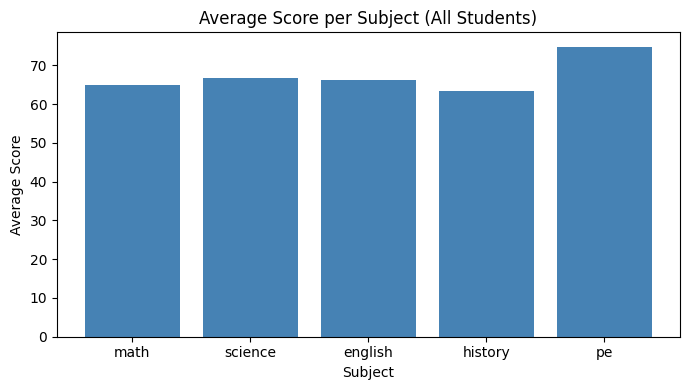

In [31]:
#Bar Chart — Average score per subject across all students 

avg_per_subject = df[subject_cols].mean()
plt.figure(figsize=(7, 4))
plt.bar(avg_per_subject.index, avg_per_subject.values, color='steelblue')
plt.title('Average Score per Subject (All Students)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.tight_layout()
plt.savefig('plot1_bar.png')
plt.show()

==
2.Histogram 
==


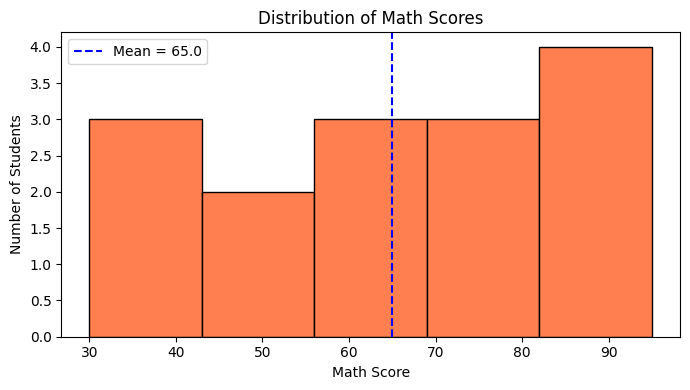

In [32]:
#Histogram — Distribution of math scores

mean_math = df['math'].mean()
plt.figure(figsize=(7, 4))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')
plt.axvline(mean_math, color='blue', linestyle='--', label=f'Mean = {mean_math:.1f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Number of Students')
plt.legend()
plt.tight_layout()
plt.savefig('plot2_hist.png')
plt.show()

==
3.Scatter Plot
==

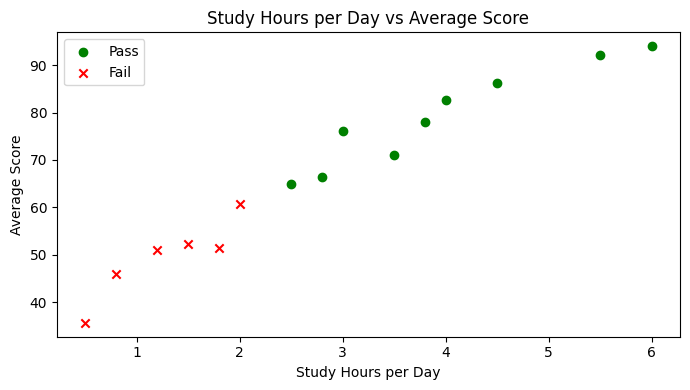

In [33]:
# Scatter Plot: Study Hours vs Avg Score

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
plt.figure(figsize=(7, 4))
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='green', label='Pass', marker='o')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='red', label='Fail', marker='x')
plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('plot3_scatter.png')
plt.show()

==
4.Box Plot
==


C:\Users\Precision\AppData\Local\Temp\ipykernel_8408\2494956959.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


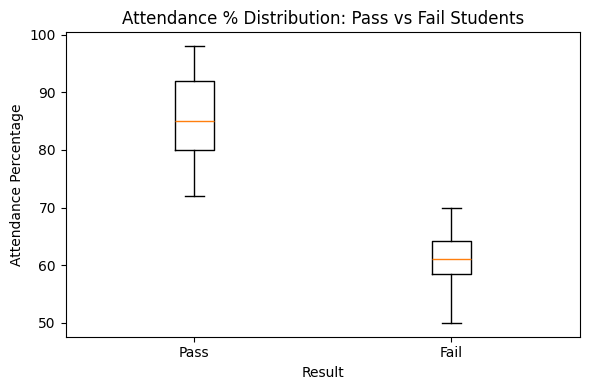

In [34]:
# the distribution of attendance_pct for passing students vs failing students 

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.figure(figsize=(6, 4))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance % Distribution: Pass vs Fail Students')
plt.xlabel('Result')
plt.ylabel('Attendance Percentage')
plt.tight_layout()
plt.savefig('plot4_box.png')
plt.show()

==
5.Line Plot
==

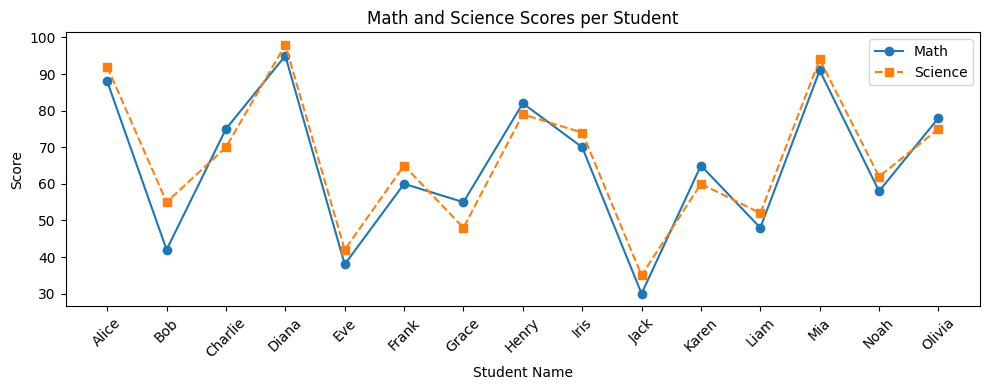

In [35]:
# Line Plot: Math & Science Score per Student

plt.figure(figsize=(10, 4))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title('Math and Science Scores per Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('plot5_line.png')
plt.show()

==
##
Task 3 — Data Visualization with Seaborn
==

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("students.csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

==
1.plot
==

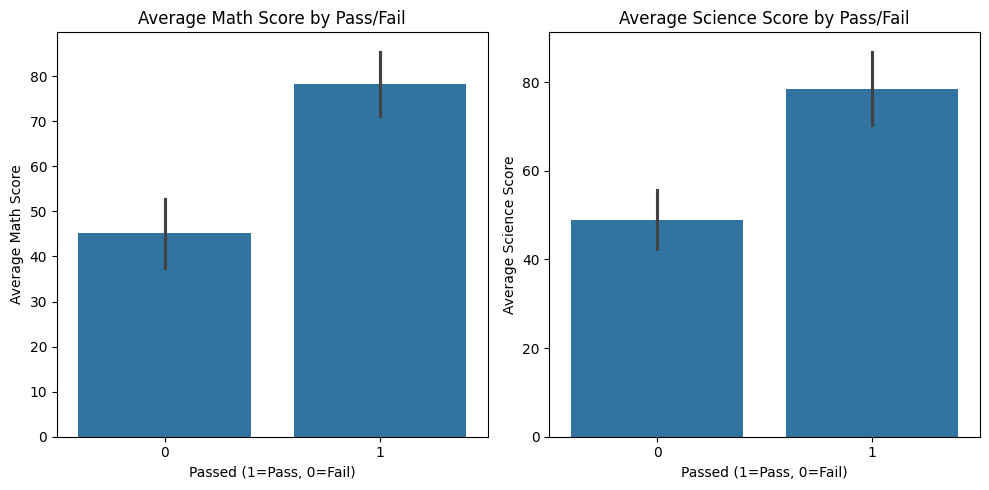

In [6]:
#Seaborn bar plot showing the average math score and average science score, split by passed (Pass vs Fail).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xlabel('Passed (1=Pass, 0=Fail)')
ax1.set_ylabel('Average Math Score')

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xlabel('Passed (1=Pass, 0=Fail)')
ax2.set_ylabel('Average Science Score')
plt.tight_layout()
plt.savefig('plot6_sns_bar.png')
plt.show()

==
2.plot
==

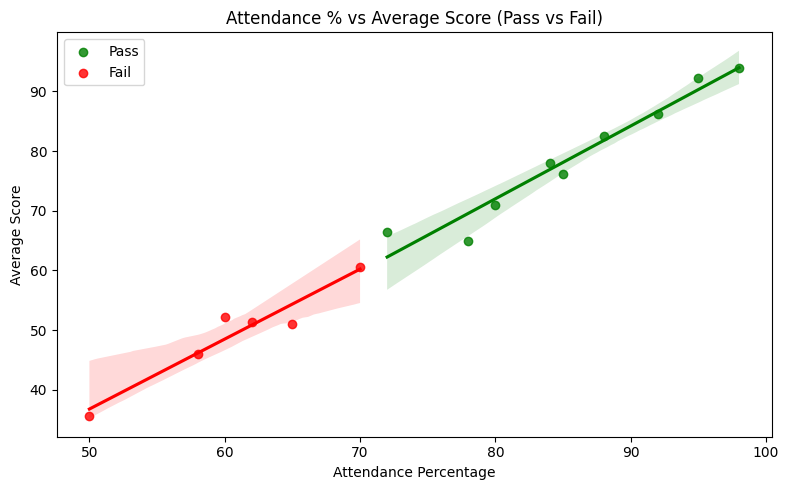

In [7]:
#Seaborn scatter plot of attendance_pct vs avg_score, coloured by passed

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            ax=ax, label='Pass', color='green', scatter_kws={'marker': 'o'})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            ax=ax, label='Fail', color='red', scatter_kws={'marker': 'x'})
ax.set_title('Attendance % vs Average Score (Pass vs Fail)')
ax.set_xlabel('Attendance Percentage')
ax.set_ylabel('Average Score')
ax.legend()
plt.tight_layout()
plt.savefig('plot7_sns_scatter.png')
plt.show()

==
#2–3 sentences of using Seaborn vs Matplotlib
==


# Seaborn vs Matplotlib:

1. Seaborn was honestly much easier to use. Like for the bar plot, I didn't have to calculate the average myself, sns.barplot() just did it on its own.

2. In Matplotlib I had to do df.mean() first and then plot it manually.The regplot() in Seaborn was also pretty cool, it drew the regression lineautomatically which would have been a lot of extra work in Matplotlib.

3. I think Seaborn is better when you just want a quick clean looking plot,but Matplotlib is more useful when you want to customize every small thing.


##

==


Task 4 — Machine Learning with scikit-learn
==

Step 1 — Prepare Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

In [4]:
# Separate features and target
feature_cols = ['math', 'science', 'english', 'history', 'pe','attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features - fit only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Step 2 — Train a Model:#

In [5]:
# Train logistic regression model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Print training accuracy
train_preds = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy:", round(train_acc, 2))

Training Accuracy: 1.0


#Step 3 — Evaluate the Model:#

In [7]:
# Predict on test set
y_pred = model.predict(X_test_scaled)

# Print test accuracy
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(test_acc, 2))

# Print each test student with actual vs predicted result
names = df.loc[X_test.index, 'name']
print()
print("Student Predictions:")
for i in range(len(y_test)):
    name = names.iloc[i]
    actual = y_test.iloc[i]
    predicted = y_pred[i]
    result = "correct" if actual == predicted else "wrong"
    print(f"{name} | Actual: {actual} | Predicted: {predicted} | {result}")

Test Accuracy: 1.0

Student Predictions:
Jack | Actual: 0 | Predicted: 0 | correct
Liam | Actual: 0 | Predicted: 0 | correct
Alice | Actual: 1 | Predicted: 1 | correct



#Step 4 — Feature Importance:#



Feature Importances (sorted by absolute value):
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.475
math: 0.4379
science: 0.323
history: 0.2629


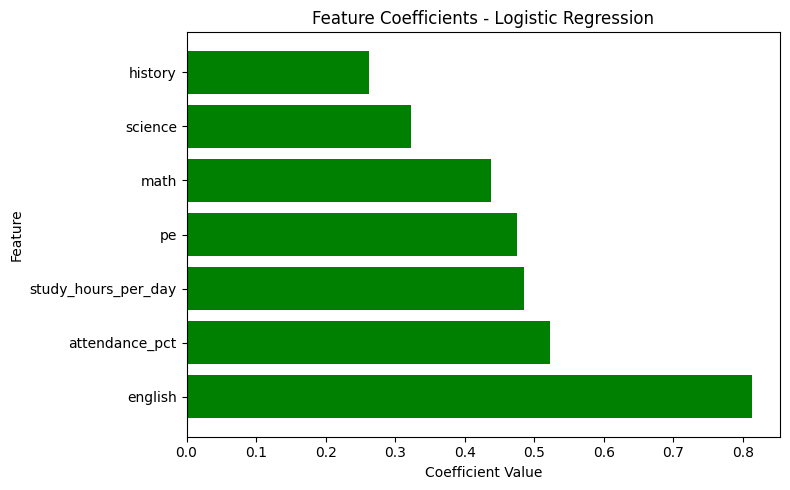

In [ ]:
# Get model coefficients
coefficients = model.coef_[0]

# Pair with feature names and sort by absolute value
coef_pairs = list(zip(feature_cols, coefficients))
coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
print()
print("Feature Importances (sorted by absolute value):")
for feat, coef in coef_pairs:
    print(f"{feat}: {round(coef, 4)}")
    
# Horizontal bar chart
feat_names = [x[0] for x in coef_pairs]
feat_coefs = [x[1] for x in coef_pairs]
bar_colors = ['green' if c > 0 else 'red' for c in feat_coefs]
plt.figure(figsize=(8, 5))
plt.barh(feat_names, feat_coefs, color=bar_colors)
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot8_feature_importance.png')
plt.show()

Step 5 — Predict for a New Student (Bonus — 2 marks):

In [12]:
# Define a new student 
# math, science, english, history, pe, attendance_pct, study_hours_per_day
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale the new student data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)
if prediction[0] == 1:
    print("Prediction: Pass")
else:
    print("Prediction: Fail")
print("Probability - Fail:", round(probability[0][0], 2),
      "| Pass:", round(probability[0][1], 2))

Prediction: Pass
Probability - Fail: 0.09 | Pass: 0.91


C:\Users\Precision\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
